---
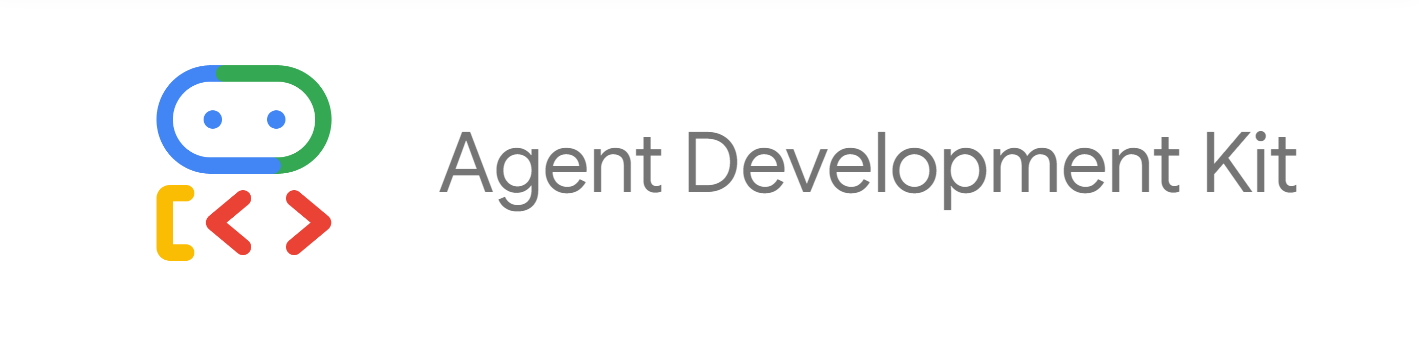

---
# Session, State And Memory in ADK

---

## **Session:** Tracking Individual Conversations
Following our Introduction, let's dive into the `Session`. Think back to the idea of a "conversation thread." Just like you wouldn't start every text message from scratch, agents need context regarding the ongoing interaction. `Session` is the ADK object designed specifically to track and manage these individual conversation threads.

## The **Session** Object
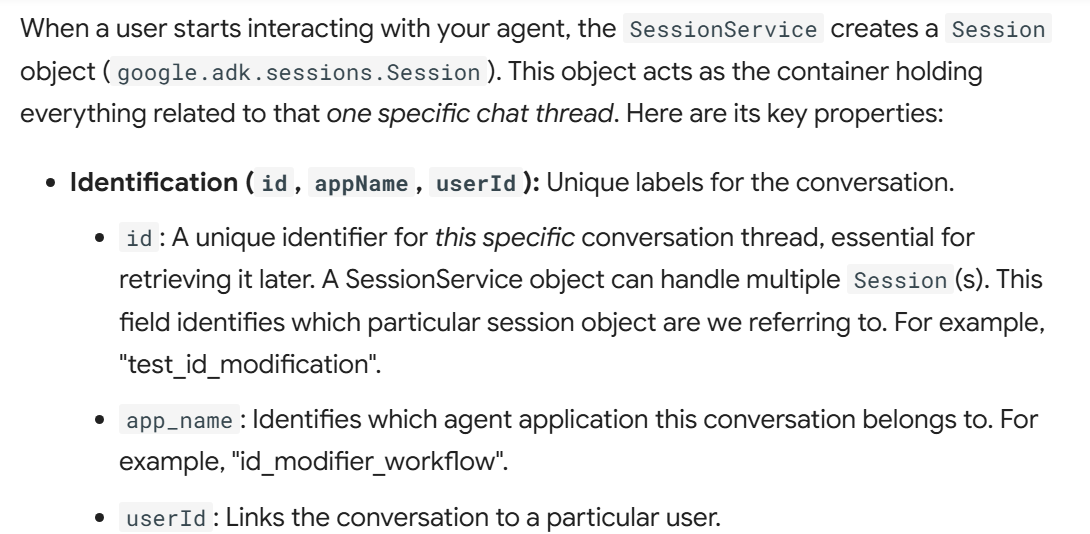 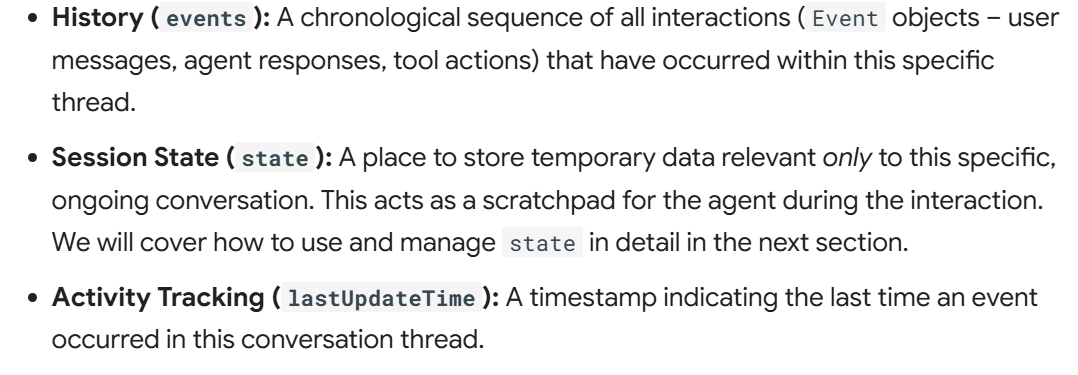 <br><br>

### `Example: Examining Session Properties`
```Python
 from google.adk.sessions import InMemorySessionService, Session

 # Create a simple session to examine its properties
 temp_service = InMemorySessionService()
 example_session = await temp_service.create_session(
     app_name="my_app",
     user_id="example_user",
     state={"initial_key": "initial_value"} # State can be initialized
 )

 print(f"--- Examining Session Properties ---")
 print(f"ID (`id`):                {example_session.id}")
 print(f"Application Name (`app_name`): {example_session.app_name}")
 print(f"User ID (`user_id`):         {example_session.user_id}")
 print(f"State (`state`):           {example_session.state}") # Note: Only shows initial state here
 print(f"Events (`events`):         {example_session.events}") # Initially empty
 print(f"Last Update (`last_update_time`): {example_session.last_update_time:.2f}")
 print(f"---------------------------------")

 # Clean up (optional for this example)
 temp_service = await temp_service.delete_session(app_name=example_session.app_name,
                             user_id=example_session.user_id, session_id=example_session.id)
 print("The final status of temp_service - ", temp_service)
```

> (Note: The state shown above is only the initial state. State updates happen via events, as discussed in the State section.)

---

## Managing Sessions with a **SessionService**
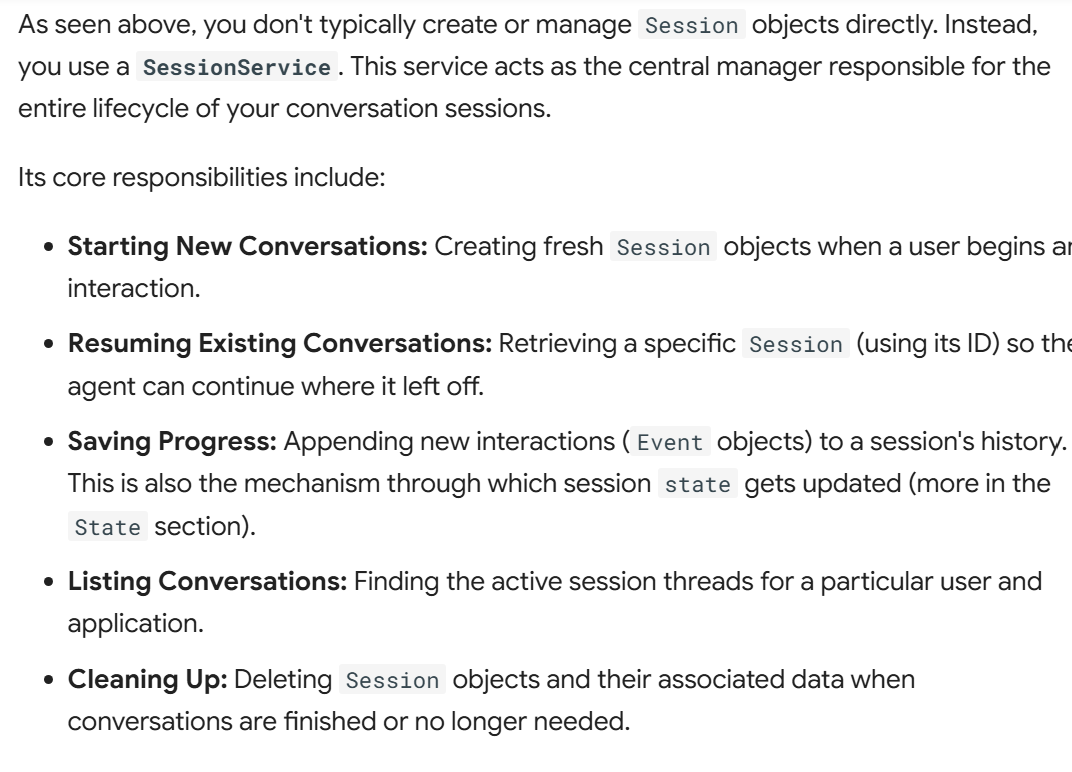 <br><br> 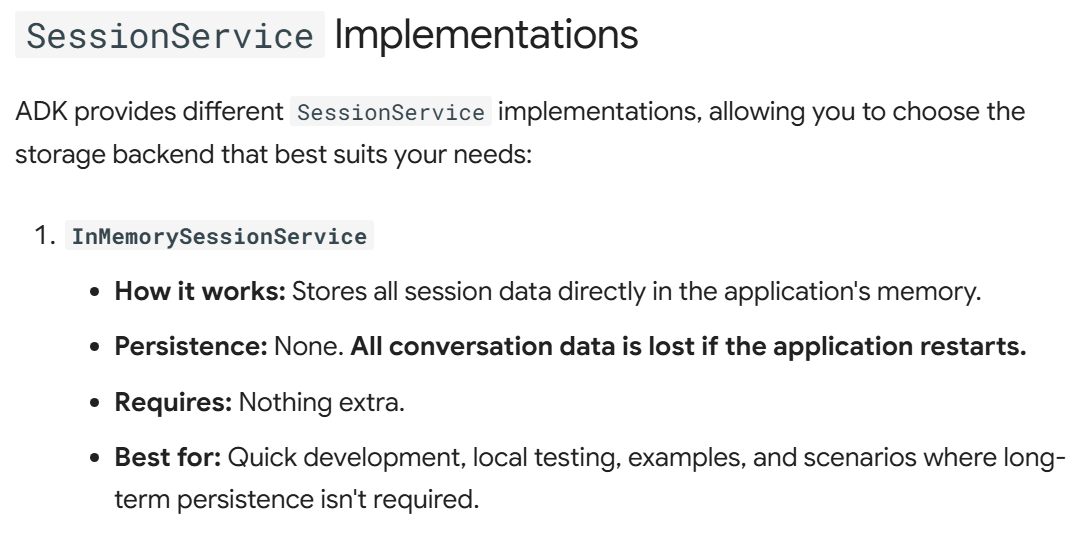 <br>

```Python
 from google.adk.sessions import InMemorySessionService
 session_service = InMemorySessionService()
```

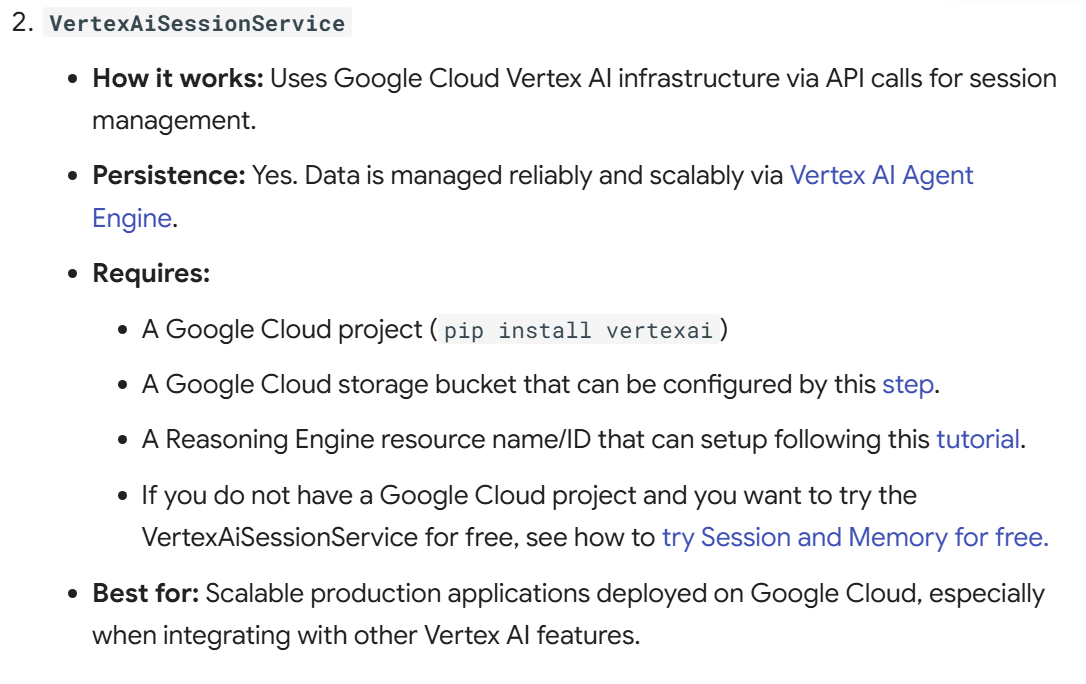 

```Python
# Requires: pip install google-adk[vertexai]
# Plus GCP setup and authentication
from google.adk.sessions import VertexAiSessionService

PROJECT_ID = "your-gcp-project-id"
LOCATION = "us-central1"
# The app_name used with this service should be the Reasoning Engine ID or name
REASONING_ENGINE_APP_NAME = "projects/your-gcp-project-id/locations/us-central1/reasoningEngines/your-engine-id"

session_service = VertexAiSessionService(project=PROJECT_ID, location=LOCATION)
# Use REASONING_ENGINE_APP_NAME when calling service methods, e.g.:
# session_service = await session_service.create_session(app_name=REASONING_ENGINE_APP_NAME, ...)
```

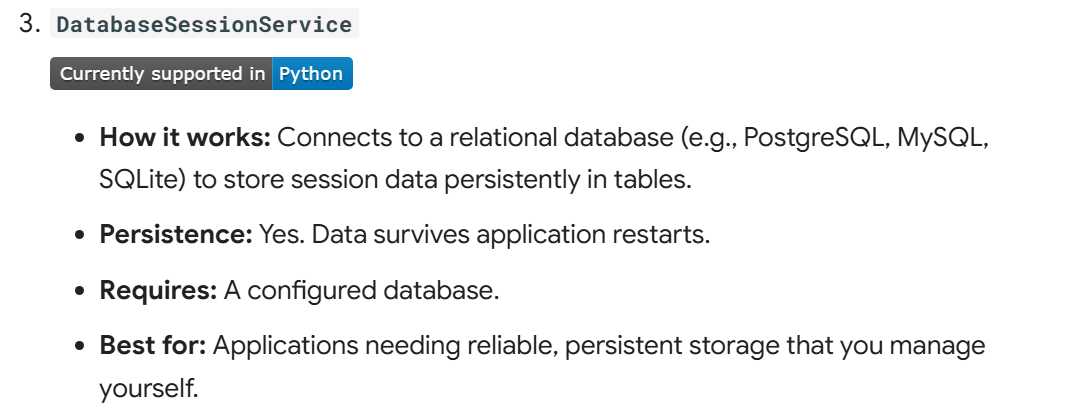

```Python
from google.adk.sessions import DatabaseSessionService
# Example using a local SQLite file:
db_url = "sqlite:///./my_agent_data.db"
session_service = DatabaseSessionService(db_url=db_url)
```

## Choosing the right `SessionService` is key to defining how your agent's conversation history and temporary data are stored and persist.

## The Session Lifecycle

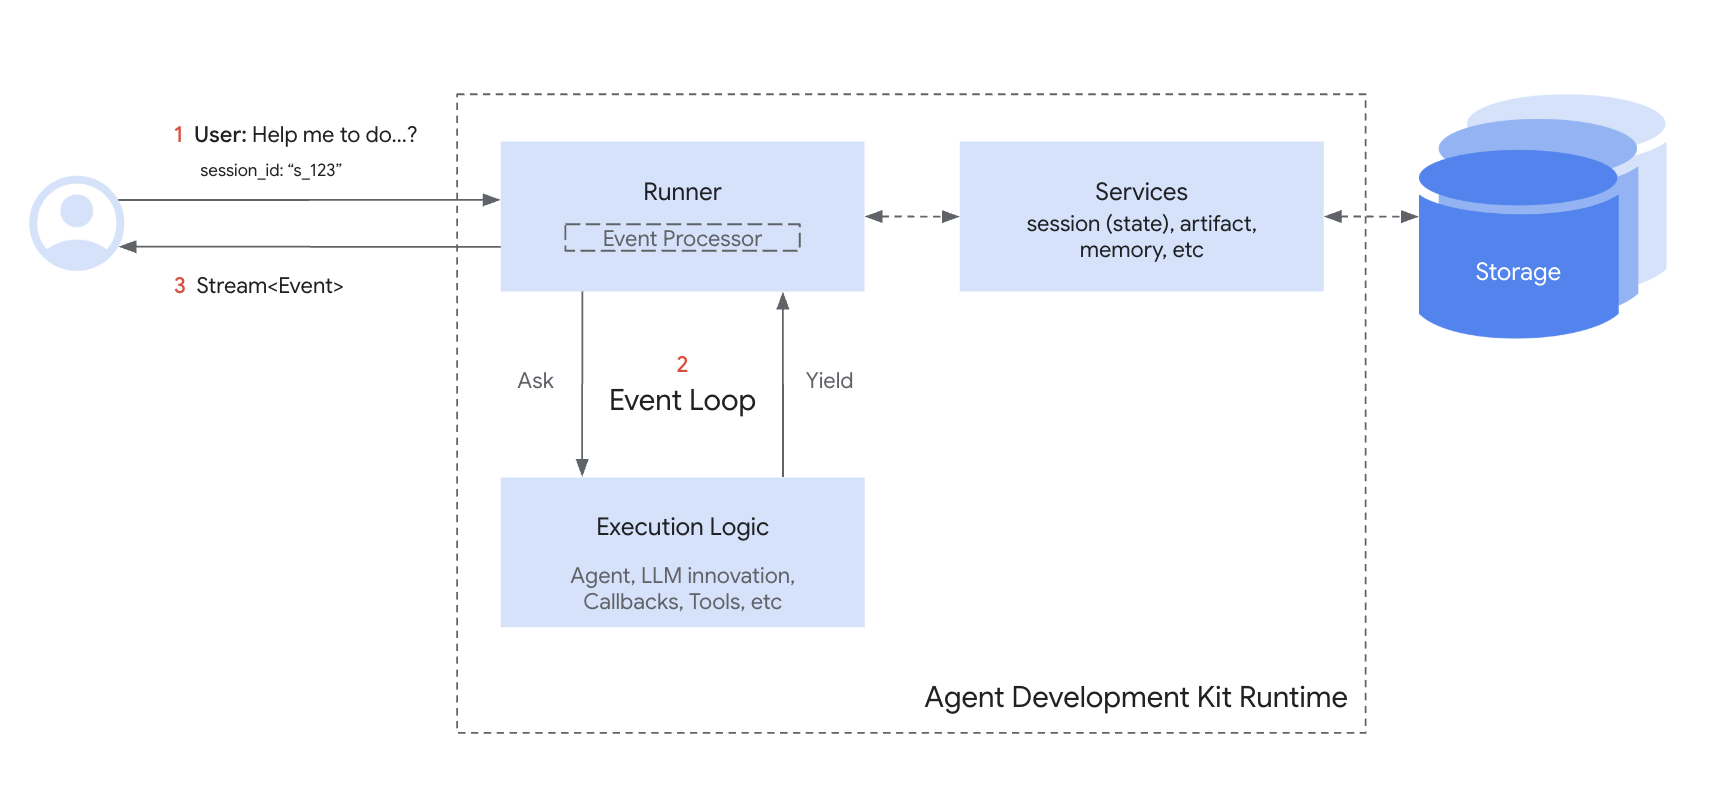

Here’s a simplified flow of how Session and SessionService work together during a conversation turn:

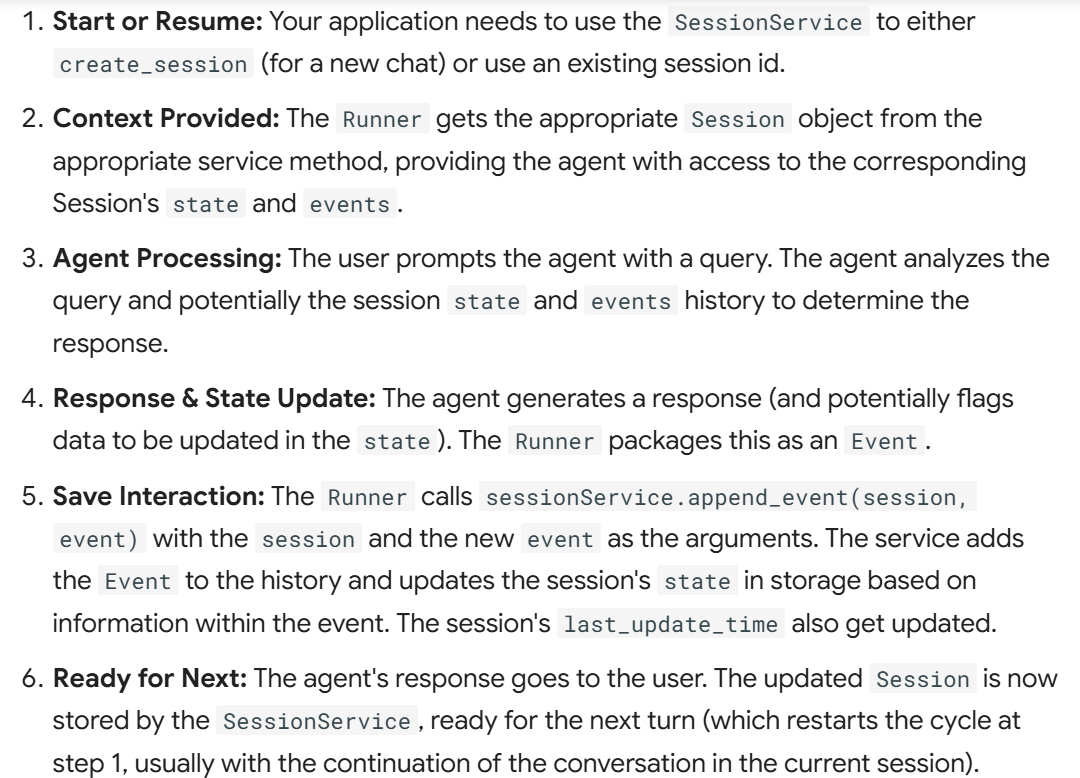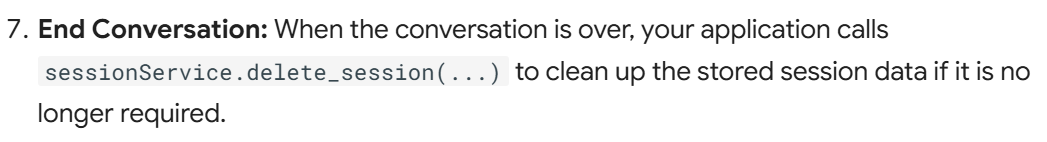

> This cycle highlights how the `SessionService` ensures conversational continuity by managing the history and state associated with each `Session` object.


---

# **State:** The Session's Scratchpad
Within each `Session` (our conversation thread), the **state** attribute acts like the agent's dedicated scratchpad for that specific interaction. While `session.events` holds the full history, `session.state` is where the agent stores and updates dynamic details needed ***during*** the conversation.

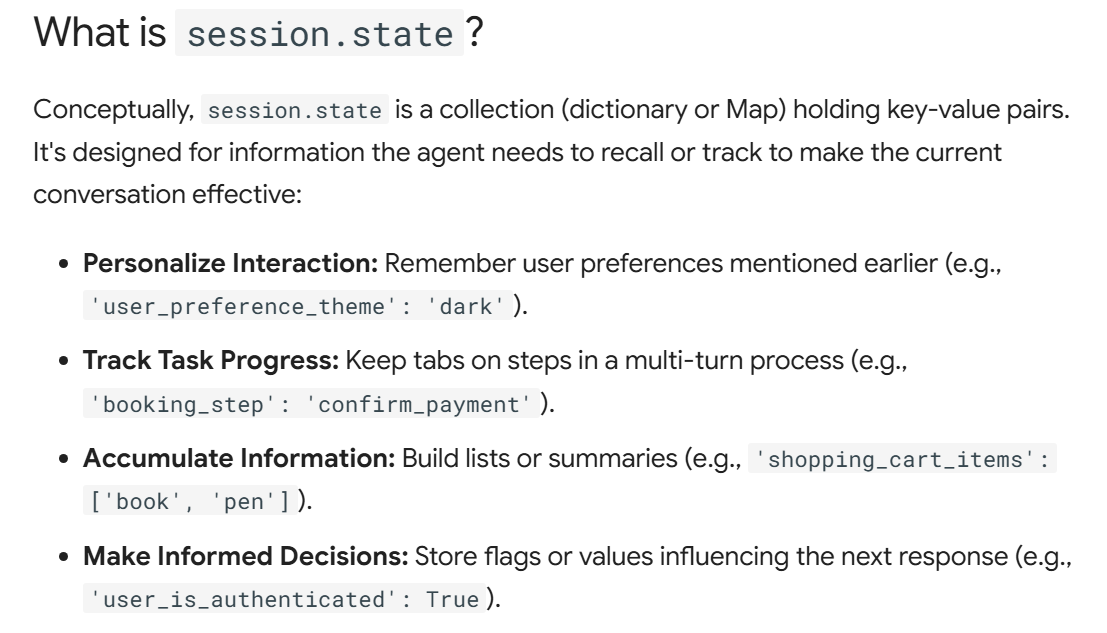 <br><br> 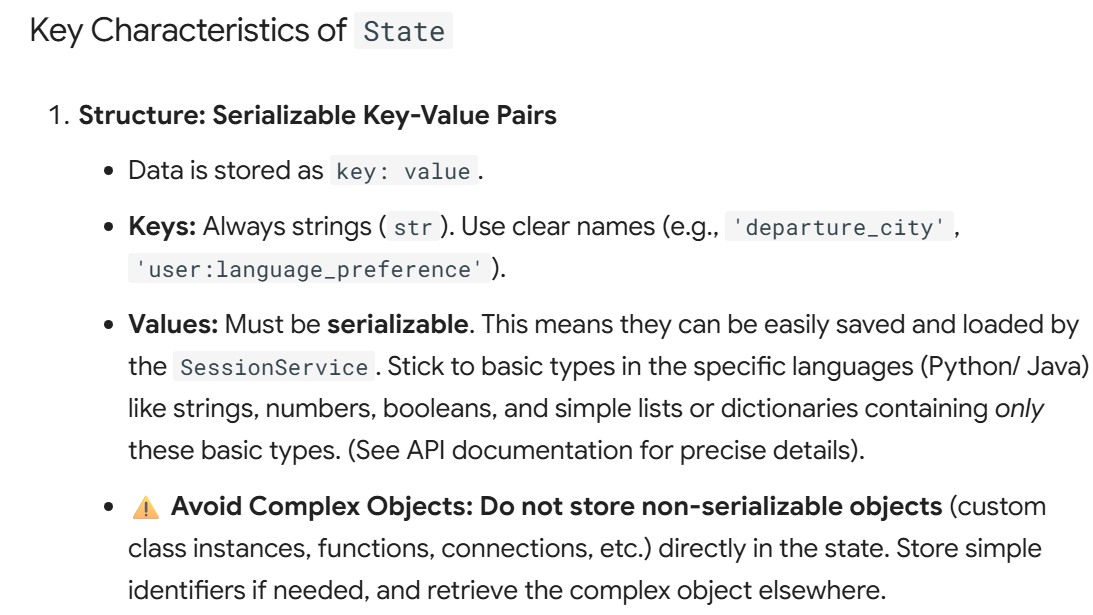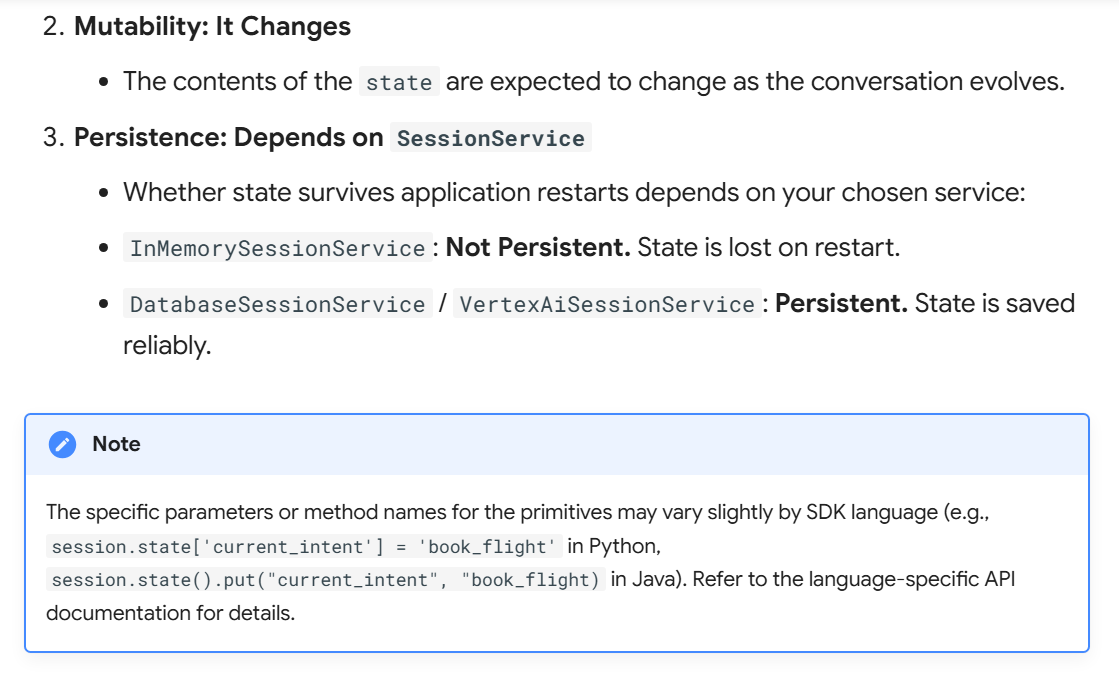 <br><br> 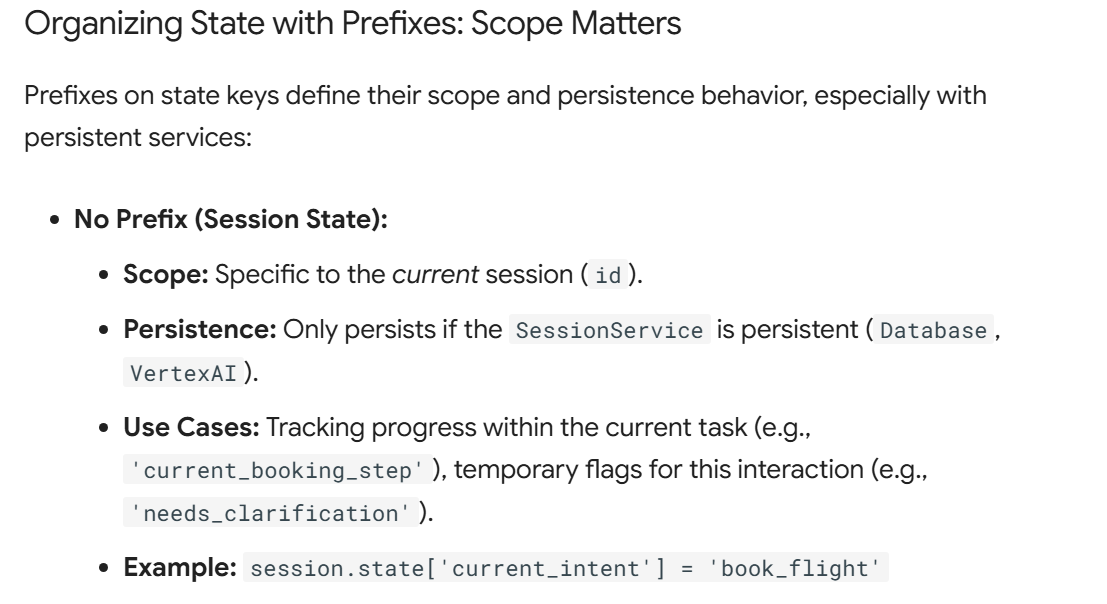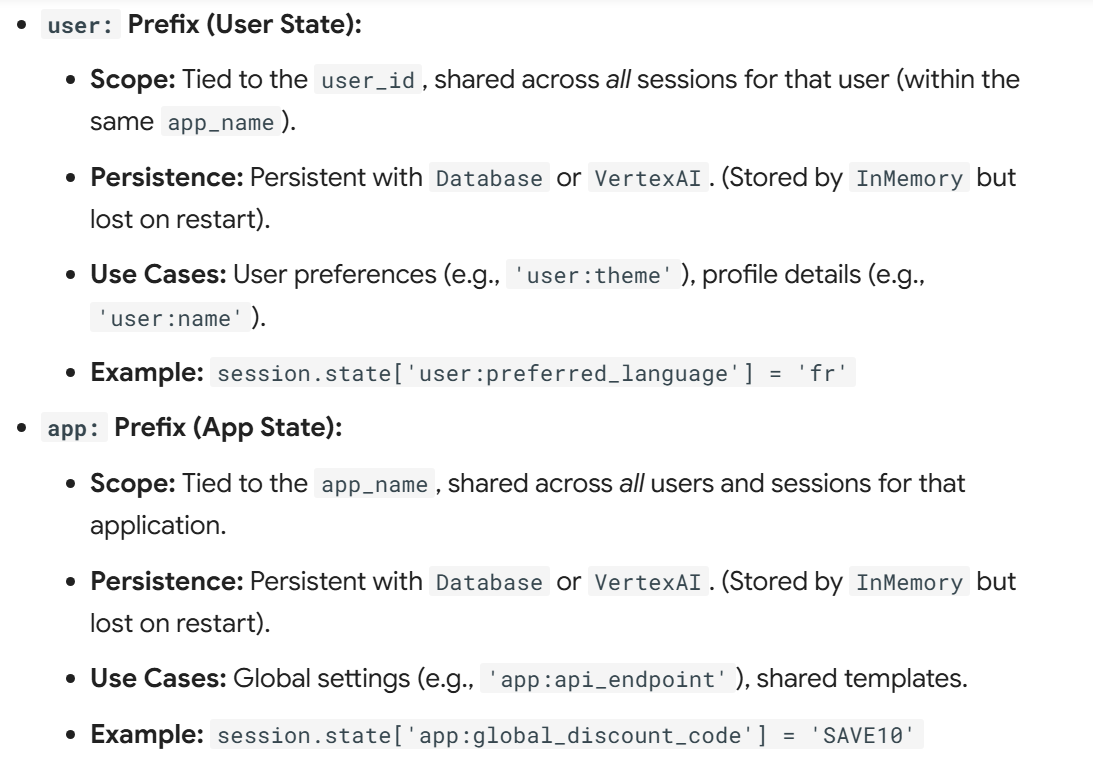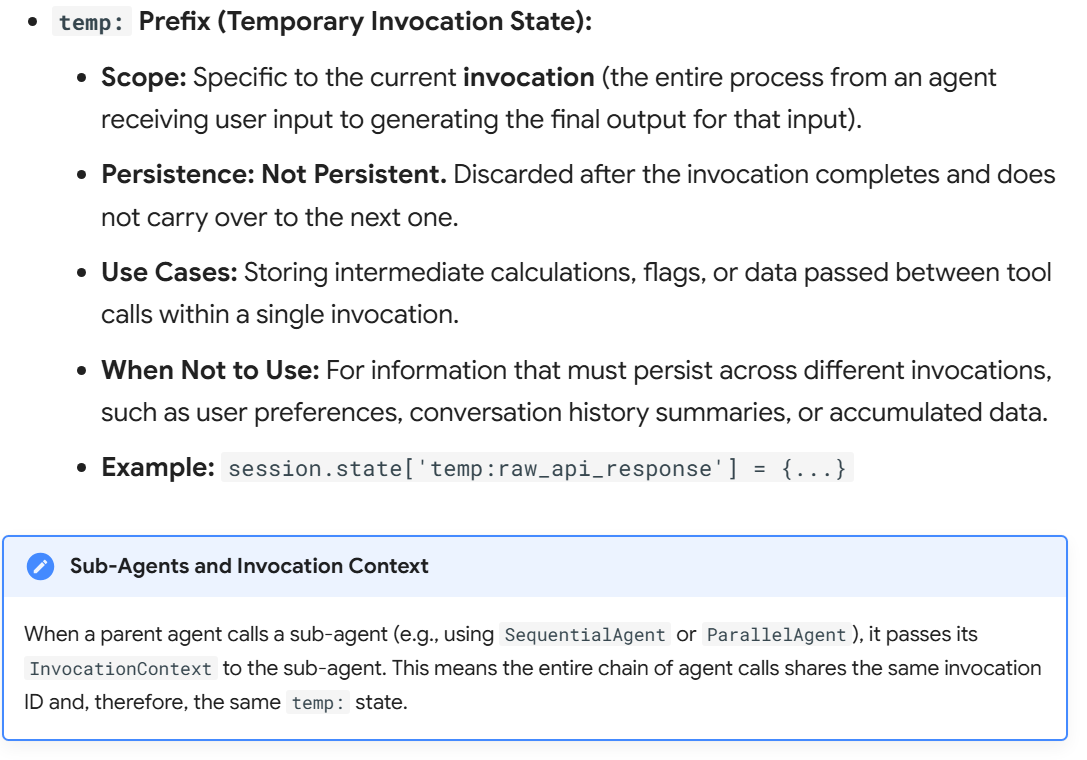 <br><br> 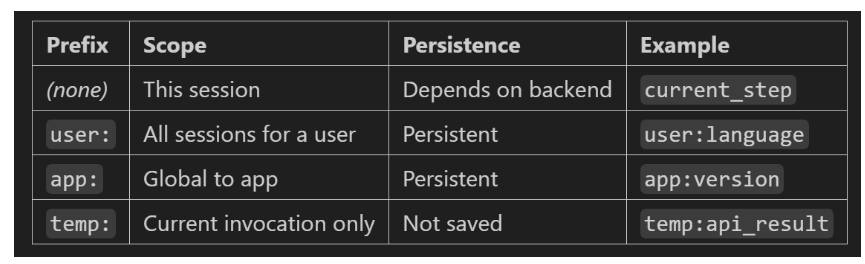 <br><br> 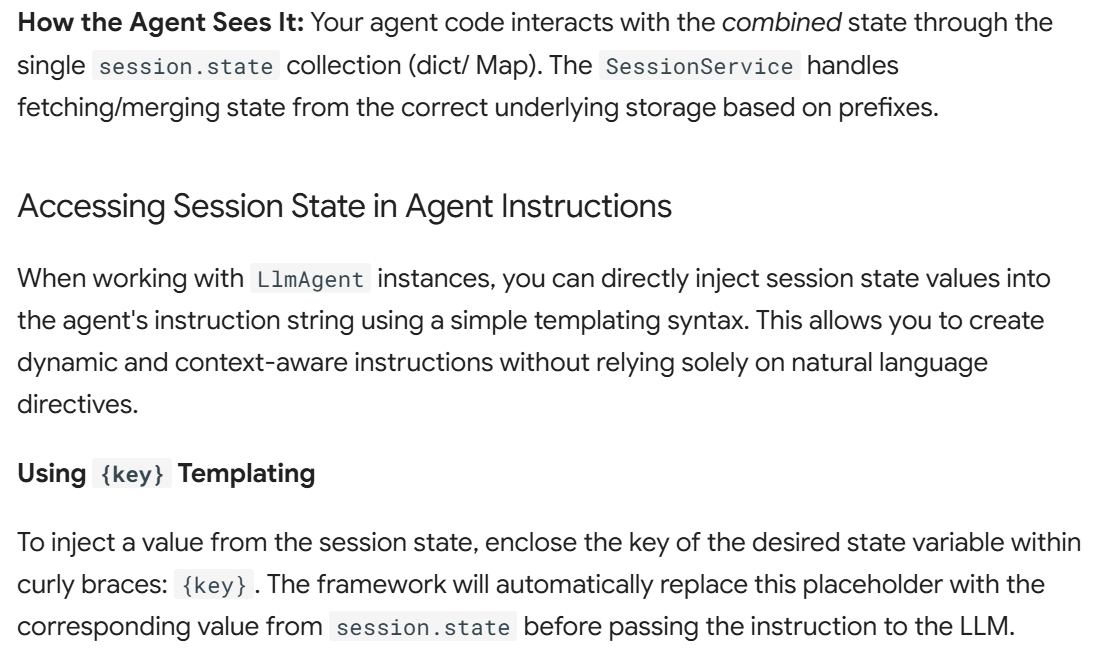 <br><br> 

### `Example`
```Python
from google.adk.agents import LlmAgent

story_generator = LlmAgent(
    name="StoryGenerator",
    model="gemini-2.0-flash",
    instruction="""Write a short story about a cat, focusing on the theme: {topic}."""
)

# Assuming session.state['topic'] is set to "friendship", the LLM 
# will receive the following instruction:
# "Write a short story about a cat, focusing on the theme: friendship."
```

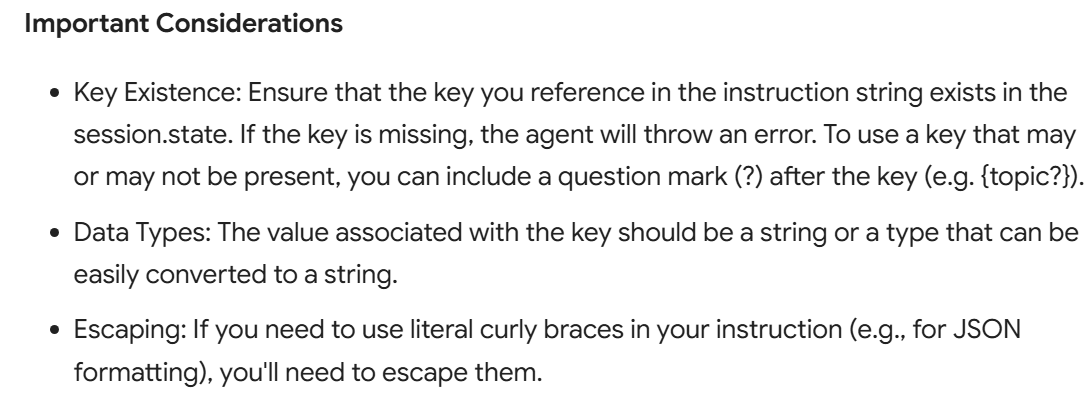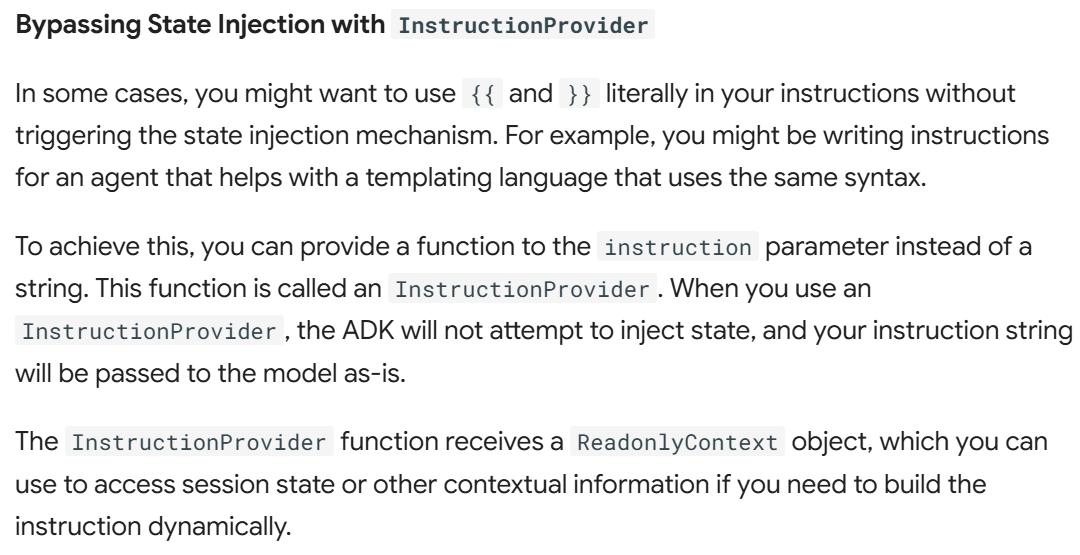 <br><br>

```Python
from google.adk.agents import LlmAgent
from google.adk.agents.readonly_context import ReadonlyContext

# This is an InstructionProvider
def my_instruction_provider(context: ReadonlyContext) -> str:
    # You can optionally use the context to build the instruction
    # For this example, we'll return a static string with literal braces.
    return "This is an instruction with {{literal_braces}} that will not be replaced."

agent = LlmAgent(
    model="gemini-2.0-flash",
    name="template_helper_agent",
    instruction=my_instruction_provider
)
```

> If you want to both use an `InstructionProvider` and inject state into your instructions, you can use the `inject_session_state` utility function.

```Python
from google.adk.agents import LlmAgent
from google.adk.agents.readonly_context import ReadonlyContext
from google.adk.utils import instructions_utils

async def my_dynamic_instruction_provider(context: ReadonlyContext) -> str:
    template = "This is a {adjective} instruction with {{literal_braces}}."
    # This will inject the 'adjective' state variable but leave the literal braces.
    return await instructions_utils.inject_session_state(template, context)

agent = LlmAgent(
    model="gemini-2.0-flash",
    name="dynamic_template_helper_agent",
    instruction=my_dynamic_instruction_provider
)
```

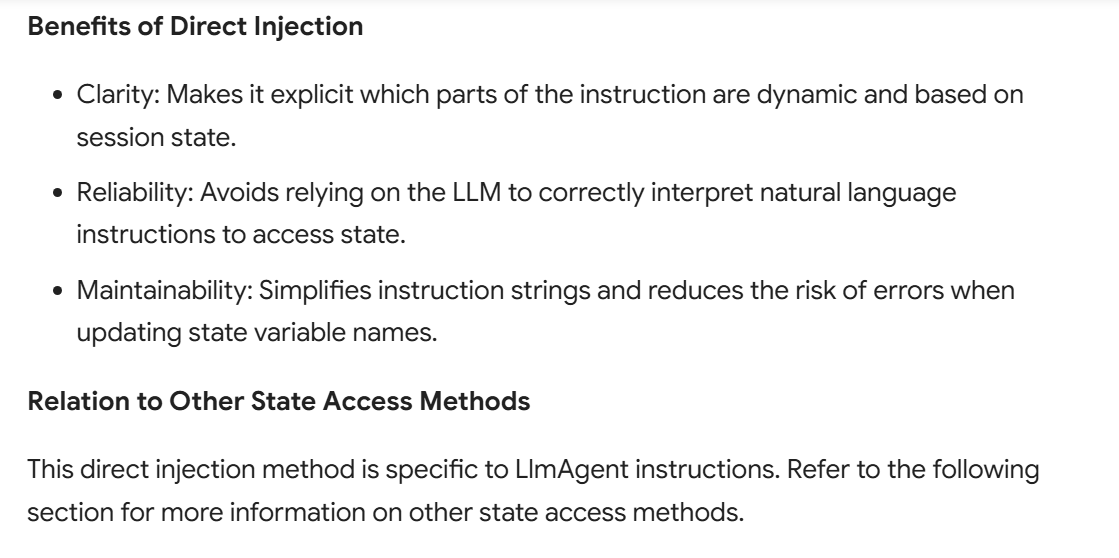

## **How State is Updated:** Recommended Methods
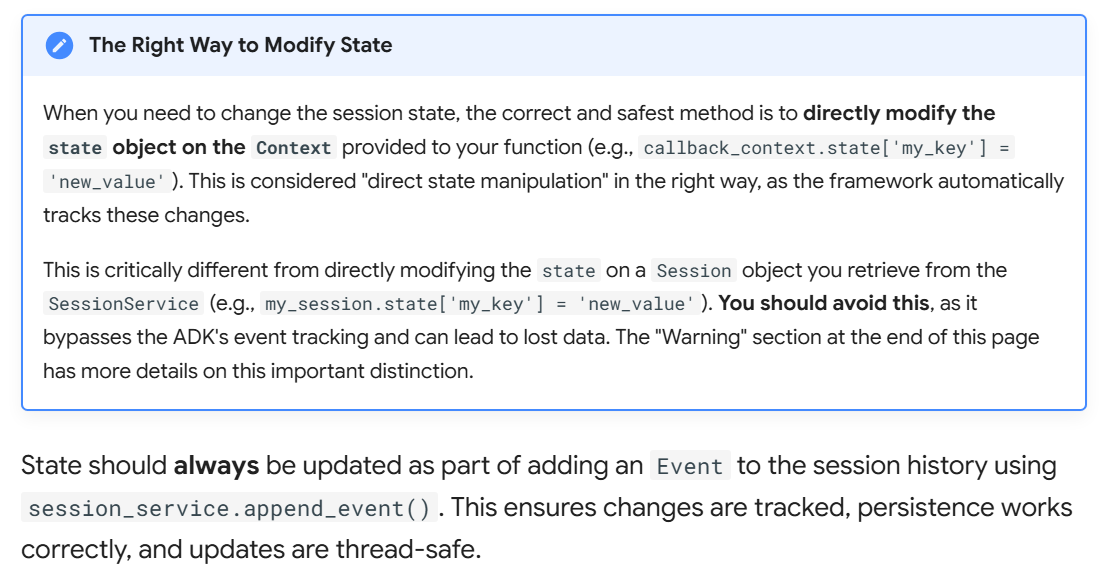 <br><br> 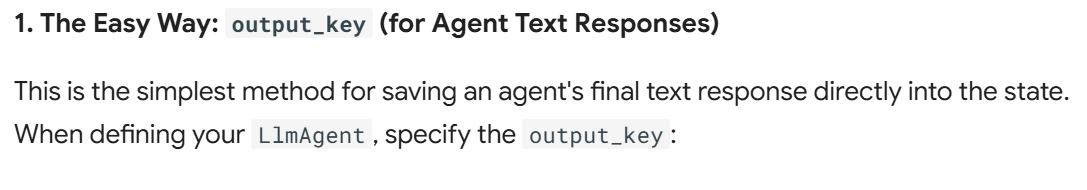

```Python
from google.adk.agents import LlmAgent
from google.adk.sessions import InMemorySessionService, Session
from google.adk.runners import Runner
from google.genai.types import Content, Part

# Define agent with output_key
greeting_agent = LlmAgent(
    name="Greeter",
    model="gemini-2.0-flash", # Use a valid model
    instruction="Generate a short, friendly greeting.",
    output_key="last_greeting" # Save response to state['last_greeting']
)

# --- Setup Runner and Session ---
app_name, user_id, session_id = "state_app", "user1", "session1"
session_service = InMemorySessionService()
runner = Runner(
    agent=greeting_agent,
    app_name=app_name,
    session_service=session_service
)
session = await session_service.create_session(app_name=app_name,
                                    user_id=user_id,
                                    session_id=session_id)
print(f"Initial state: {session.state}")

# --- Run the Agent ---
# Runner handles calling append_event, which uses the output_key
# to automatically create the state_delta.
user_message = Content(parts=[Part(text="Hello")])
for event in runner.run(user_id=user_id,
                        session_id=session_id,
                        new_message=user_message):
    if event.is_final_response():
      print(f"Agent responded.") # Response text is also in event.content

# --- Check Updated State ---
updated_session = await session_service.get_session(app_name=APP_NAME, user_id=USER_ID, session_id=session_id)
print(f"State after agent run: {updated_session.state}")
# Expected output might include: {'last_greeting': 'Hello there! How can I help you today?'}
```

> Behind the scenes, the `Runner` uses the `output_key` to create the necessary EventActions with a `state_delta` and calls `append_event`. <br>

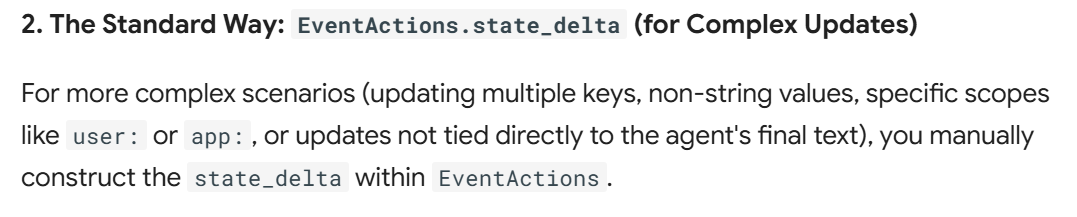

```Python
from google.adk.sessions import InMemorySessionService, Session
from google.adk.events import Event, EventActions
from google.genai.types import Part, Content
import time

# --- Setup ---
session_service = InMemorySessionService()
app_name, user_id, session_id = "state_app_manual", "user2", "session2"
session = await session_service.create_session(
    app_name=app_name,
    user_id=user_id,
    session_id=session_id,
    state={"user:login_count": 0, "task_status": "idle"}
)
print(f"Initial state: {session.state}")

# --- Define State Changes ---
current_time = time.time()
state_changes = {
    "task_status": "active",              # Update session state
    "user:login_count": session.state.get("user:login_count", 0) + 1, # Update user state
    "user:last_login_ts": current_time,   # Add user state
    "temp:validation_needed": True        # Add temporary state (will be discarded)
}

# --- Create Event with Actions ---
actions_with_update = EventActions(state_delta=state_changes)
# This event might represent an internal system action, not just an agent response
system_event = Event(
    invocation_id="inv_login_update",
    author="system", # Or 'agent', 'tool' etc.
    actions=actions_with_update,
    timestamp=current_time
    # content might be None or represent the action taken
)

# --- Append the Event (This updates the state) ---
await session_service.append_event(session, system_event)
print("`append_event` called with explicit state delta.")

# --- Check Updated State ---
updated_session = await session_service.get_session(app_name=app_name,
                                            user_id=user_id,
                                            session_id=session_id)
print(f"State after event: {updated_session.state}")
# Expected: {'user:login_count': 1, 'task_status': 'active', 'user:last_login_ts': <timestamp>}
# Note: 'temp:validation_needed' is NOT present.
```

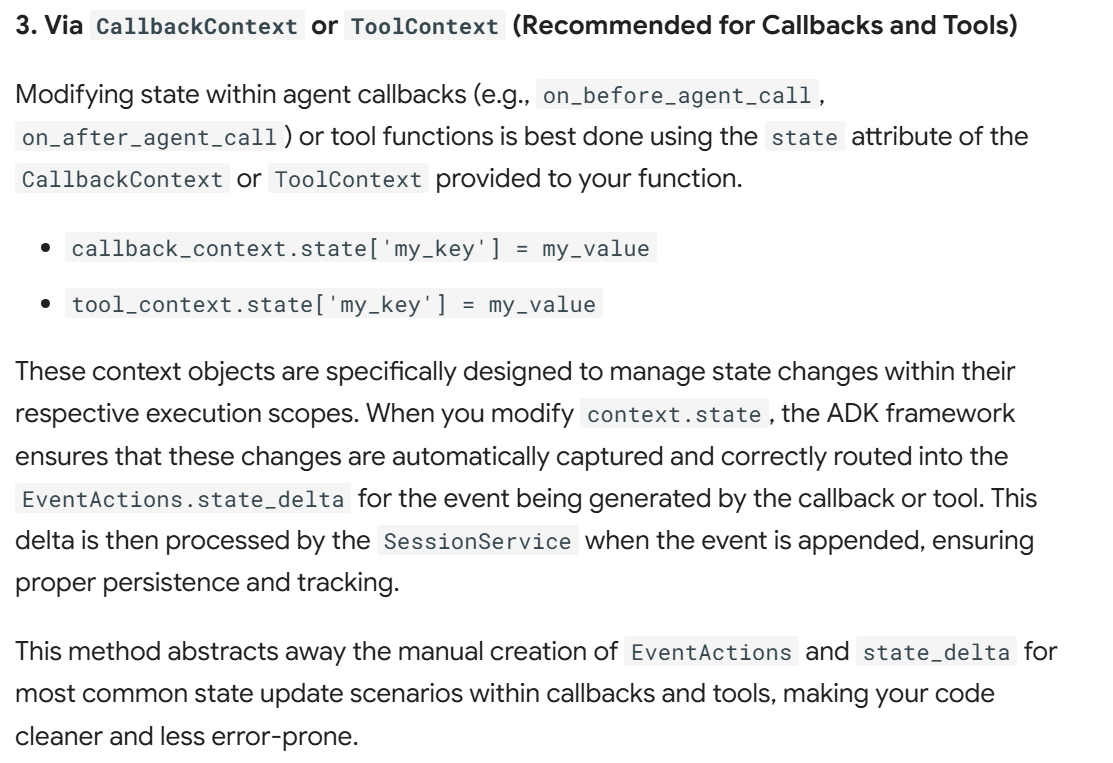

For more comprehensive details on context objects, refer to the [Context documentation](https://google.github.io/adk-docs/context/).

```Python
# In an agent callback or tool function
from google.adk.agents import CallbackContext # or ToolContext

def my_callback_or_tool_function(context: CallbackContext, # Or ToolContext
                                 # ... other parameters ...
                                ):
    # Update existing state
    count = context.state.get("user_action_count", 0)
    context.state["user_action_count"] = count + 1

    # Add new state
    context.state["temp:last_operation_status"] = "success"

    # State changes are automatically part of the event's state_delta
    # ... rest of callback/tool logic ...
```
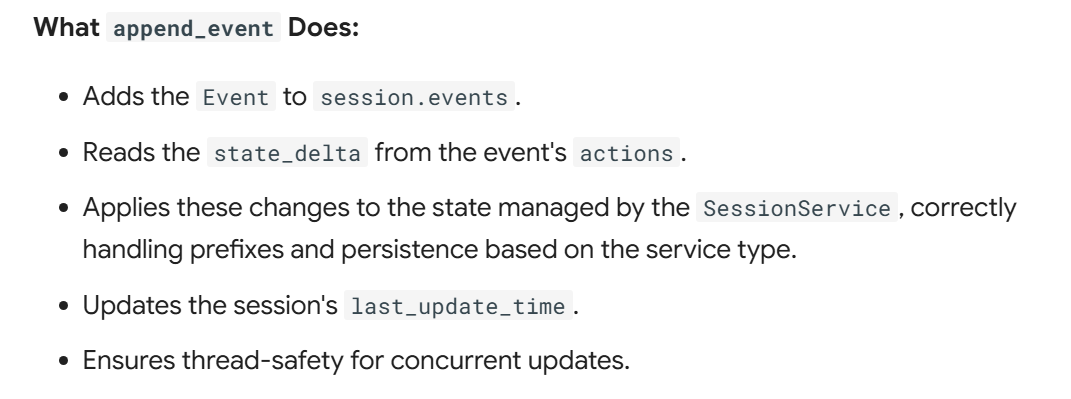 <br><br>

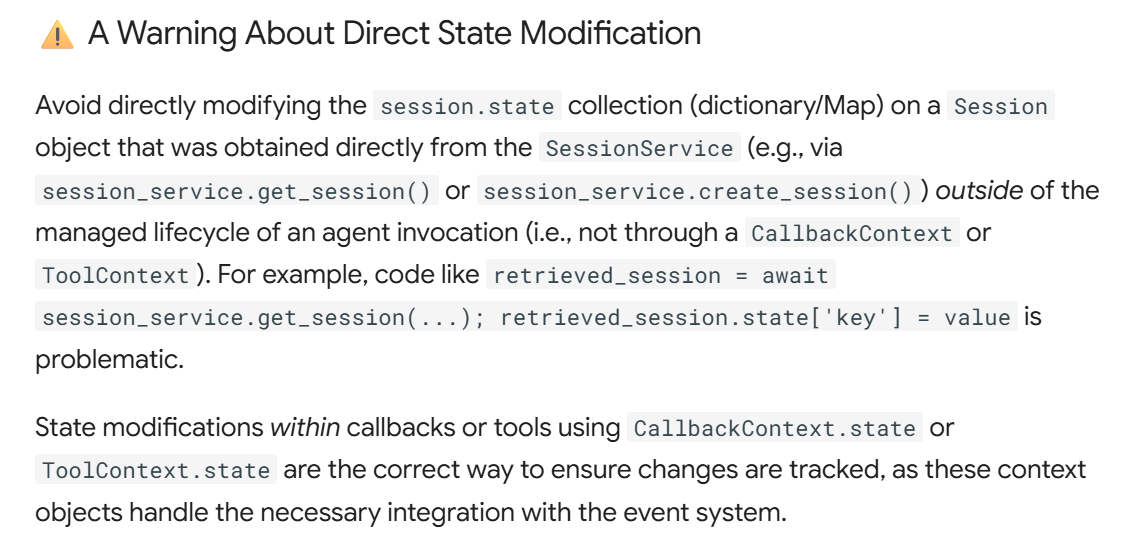 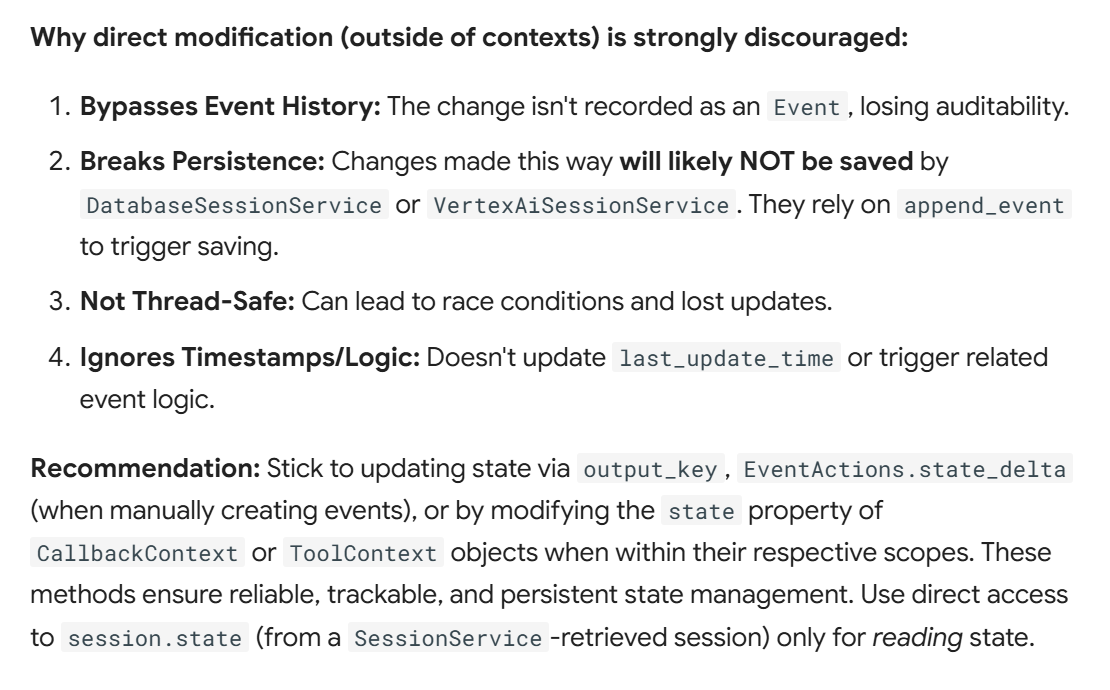

## Best Practices for State Design Recap

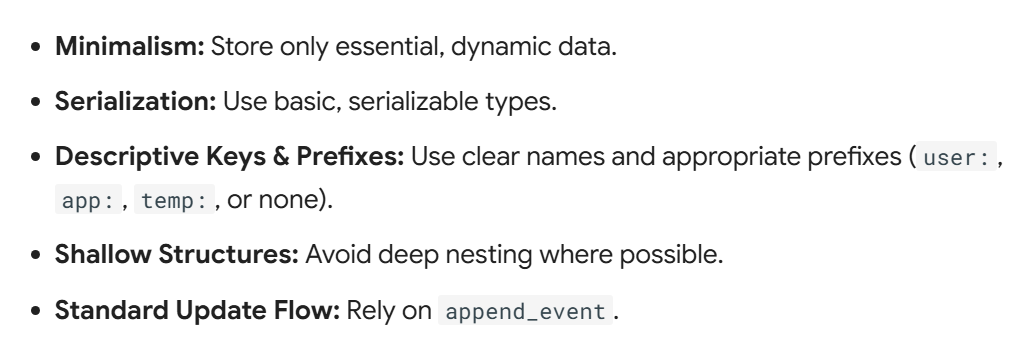

---